### Import Libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV




### Load data

In [18]:
X_test_scaled = np.load('../data/processed/X_test_scaled.npy')
X_train_scaled = np.load('../data/processed/X_train_scaled.npy')
y_test = np.load('../data/processed/y_test.npy')
y_train= np.load('../data/processed/y_train.npy')

### Hyperparameters tuning

In [19]:
# define parameter grid 
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[5,10,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# create base model
rf = RandomForestClassifier(random_state=42)

# create GridSearchCV

grid_search = GridSearchCV(
    estimator=rf,#what model are we tuning
    param_grid=param_grid,# parameters searching
    cv=5,
    scoring='accuracy'

)
# fit
grid_search.fit(X_train_scaled,y_train)

# best parameters 
print('Best Parameters:',grid_search.best_params_)
print("Best Score:",grid_search.best_score_)


Best Parameters: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Score: 0.8998667711598747


### Build the final model

In [20]:
rf_final = RandomForestClassifier(
    bootstrap = True,
    max_depth = 20,
    min_samples_leaf = 1,
    min_samples_split = 5,
    n_estimators=100,
    random_state = 42
)

rf_final.fit(X_train_scaled,y_train)
y_pred_rf = rf_final.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("\nClassification Report:\n",classification_report(y_test,y_pred_rf))

Accuracy: 0.9175

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.92      0.91      0.91       100
           2       0.84      0.89      0.86       100
           3       0.95      0.89      0.92       100

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



### Feature Importance

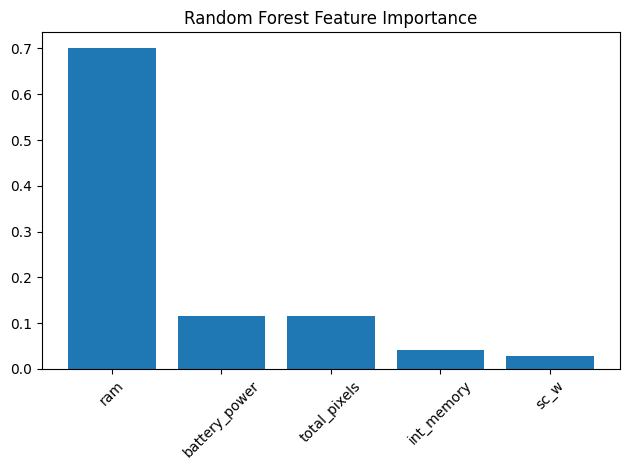

In [22]:
#feature importance plot
feature_names = ['ram','battery_power','total_pixels','int_memory','sc_w']

importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.Figure(figsize=(12,6))
plt.bar(range(5),importances[indices])
plt.xticks(range(5),[feature_names[i] for i in indices],rotation=45)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### Save the model

In [24]:
import joblib
joblib.dump(rf_final,'../models/rf_model.pkl')
print("RF Model saved successfuly.")

RF Model saved successfuly.
